# **Parsing Binry Tree**

Binary tree dapat digunakan untuk beberapa aplikasi seperti penyelesaian persamaan matematika. Misalkan terdapat persamaan $((7 + 3) * (5 -2))$. Penyelesaian persamaan
matematika tergantung pada operator precedence dan keberadaan kurung. Jika terdapat tanda
kurung buka maupun tutup, maka persamaan di dalam kurung tersebut haruslah diselesaikan
pertama kali walapun level operator precedence lebih rendah dibandingkan operator yang berada
di luar kurung.


Penyelesaian persamaan matematika ini dapat juga diselesaikan dengan menggunakan bantuan
dari **binary tree**, seperti yang terdapat pada Gambar 1 berikut: 


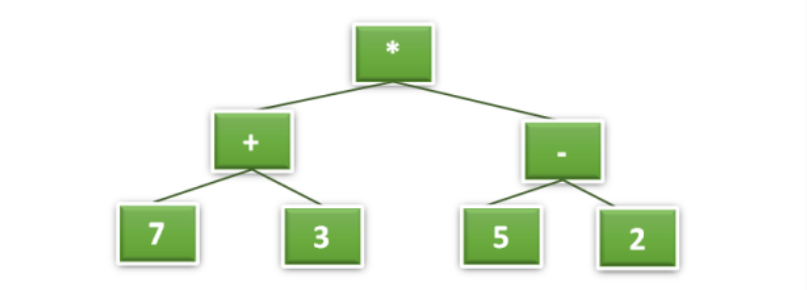

**Gambar 1. Binary Tree untuk Persamaan** ((7 + 3) ∗ (5 − 2))

Pada Gambar 1 tersebut dapat artikan bahwa penjumlahan antara 7 dan 3 haruslah dikerjakan
terlebih dahulu sebelum operasi perkalian. Begitu juga pengurangan 5 dan 2 harus dikerjakan
terlebih dahulu sebelum dilakukan operasi perkalian. Left subtree dan right subtree dapat diganti
dengan hasil penjumlahan maupun perkalian seperti Gambar 2.

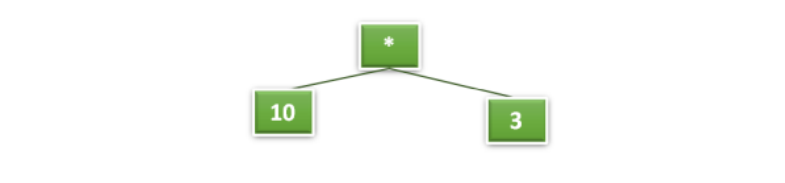

**Gambar 2. Penyelesaian tahap awal Persamaan Matematika** ((7 + 3) ∗ (5 − 2))

<a id="menu"></a>
Terdapat dua tahapan untuk menyelesaikan Persamaan Matematikan tersebut, dengan menggunakan Binary Tree, yaitu :
1. [Pembentukan Parse Tree](#pembentukan)
2. [Evaluasi Persamaan Matematika](evaluasi)

<a id="pembuatan"></a>
## **Pembuatan Parse Tree untuk Ekspresi Matematika**

Persamaan Matematika harus dipecah menjadi list token agar dapat dibuat menjadi parse tree. Token-token untuk persamaan Matematika tersebut antara lain:
- Kurung buka, kurung buka ini menandakan ekspressi baru yang akan dioperasi, oleh karena itu perlu dibuat subtree baru untuk menyelesaikan ekspressi baru ini
- kurung tutup, kurung tutup ini menandakan akhir dari ekspressi matematika
- operand, operand ini yang akan jadi *leaf node* dan *children* dari operator
- operator, operator merupakan *parent* dan punya *left* maupun *right child*

Berikut algoritma untuk membuat parse tree ekspressi matematika:
1. Jika current token adalah kurung buka, '(' , tambahkan node baru sebagai left child dari
current Node dan jadikan node baru ini sebagai current node
2. jika current token adalah operator, set nilai key dari current node dengan operator tersebut.
Tambahkan node baru sebagai right child dari current node, jadikan right child ini sebagai
current node
3. jika current token adalah operand, maka set nilai key dari current node dengan operand
tersebut dan jadikan parent dari node tersebut menjadi current node
4. jika current token adalah kurung tutup, ')', maka kembali ke parent dari current node

Berikut contoh pembuatan parse tree untuk ekpressi matematika $(3+4(4*5))$. Tahapan
pembuatan parse tree dapat dilihat pada Gambar 3 berikut: 

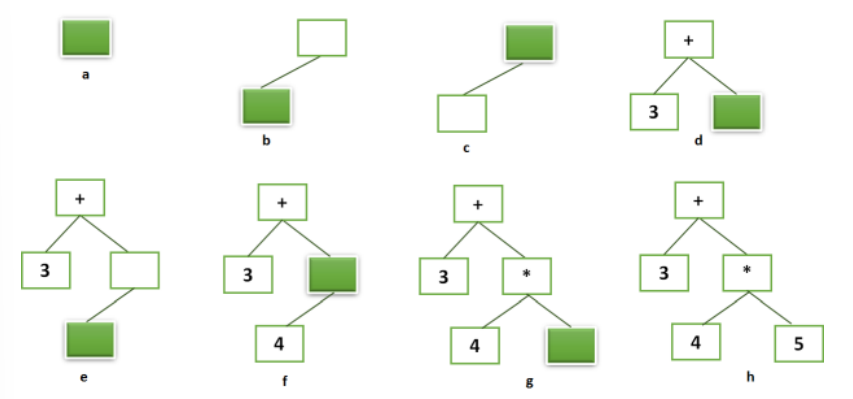

**Gambar 3. Tahapan pembuatan binary tree untuk Persamaan** $(3+4(4*5))$

Binary tree class sebelumnya menyediakan method-method untuk menambah node baru baik sebelah kiri maupun kanan, dan menuju left child maupun right child. Method-method ini sangat diperlukan untuk pembuatan parse tree. Akan tetapi berdasarkan algoritma pembuatan parse tree diatas, **terdapat perintah untuk kembali menuju parent dari current node**. Hal ini tidak dapat
dilakukan oleh method yang terdapat pada binary tree class sebelumnya. Diperlukan struktur
**data stack**, untuk menyimpan parent dari current node. Jika pointer ingin menuju left child dari
current node, maka push current node tersebut ke dalam stack, dan ketika ingin kembali ke parent
dari current node maka pop node yang terdapat pada stack.


### Code

Berikut code untuk parsing atau pembuatan binary tree untuk persamaan matematika

In [19]:
def stack():
    s = []
    return s

def push(s, data):
    s.append(data)
    return s

def pop(s):
    data = s.pop()
    return (data)

def peek(s):
    return (s[len(s)-1])

def isEmpty(s):
    return (s==[])

def size(s):
    return len(s)

In [20]:
class BinaryTree:
    def __init__(self, root):
        self.key = root
        self.leftChild = None
        self.rightChild = None
        
    def insertLeft(self, new_node):
        if self.leftChild == None:
            self.leftChild = BinaryTree(new_node)
        else:
            t = BinaryTree(new_node)
            t.leftChild = self.leftChild
            self.leftChild = t
            
    def insertRight(self, new_node):
        if self.rightChild == None:
            self.rightChild = BinaryTree(new_node)
        else:
            t = BinaryTree(new_node)
            t.rightChild = self.rightChild
            self.rightChild = t
            
    def getRightChild(self):
        return self.rightChild
        
    def getLeftChild(self):
        return self.leftChild
        
    def setRootVal(self, obj):
        self.key = obj
        
    def getRootVal(self):
        return self.key

In [21]:
def buildParseTree(mathExp):
    tokenList = mathExp.split()
    parentStack = stack()
    expTree = BinaryTree(' ' )
    push(parentStack,expTree)
    print(tokenList)
    currentTree = expTree
    for i in tokenList:

        if i == '(' :
            print('if 1', i)
            currentTree.insertLeft(' ' )
            push(parentStack,currentTree)
            currentTree = currentTree.getLeftChild()
        elif i not in [ '+' , '-' , '*' , '/' , ')' ]:
            print('if 2', i)
            currentTree.setRootVal(int(i))

            parent = pop(parentStack)
            currentTree = parent
        elif i in [ '+' , '-' , '*' , '/' ]:
            print('if 3', i)
            currentTree.setRootVal(i)
            currentTree.insertRight(' ' )
            push(parentStack,currentTree)
            currentTree = currentTree.getRightChild()
        elif i == ')' :

            currentTree = pop(parentStack)
        else:
            raise ValueError
    return expTree


In [22]:
pt = buildParseTree(' ( 3 + ( 4 * 5 ) ) ')

['(', '3', '+', '(', '4', '*', '5', ')', ')']
if 1 (
if 2 3
if 3 +
if 1 (
if 2 4
if 3 *
if 2 5


In [23]:
print(pt.getRootVal())
tmp=pt.getLeftChild()
print(tmp.getRootVal())

+
3


In [24]:
if pt.getLeftChild():
    print("Tree")

Tree


[Kembali ke Menu Awal](#menu)

<a id="evaluasi"></a>
## **Evaluasi Persamaan Matematika**

Misalkan terdapat persamaan $((2+5)*3)$, maka binary tree dari persamaan matematika
tersebut ditunjukkan oleh Gambar 4 berikut. 

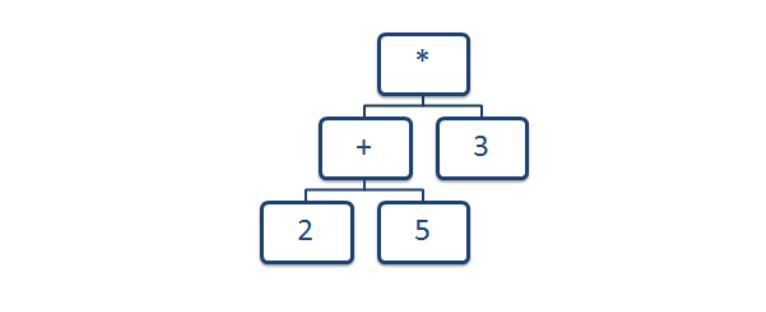

**Gambar 4. Binary Tree untuk Persamaan** $((2+5)*3)$

Dari gambar tersebut dapat disimpulkan bahwa, untuk menyelesaikan persamaan matematika $((2+5)*3)$, maka node '2' dan node '5' harus diselesaikan terlebih dahulu dengan operasi '+',
sehingga binary tree tersebut dapat diganti menjadi Gambar 5 berikut.

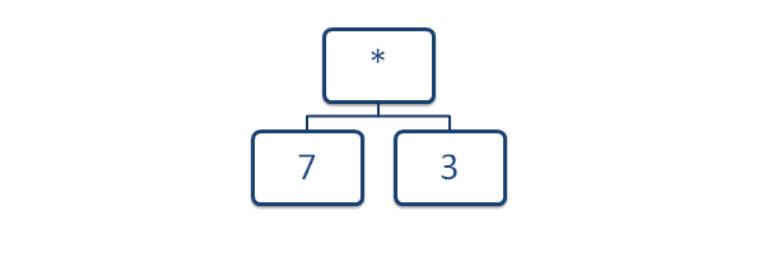

**Gambar 5. Penyelesaian tahap awal untuk Persamaan** $((2+5)*3)$

Oleh karena itu, untuk menyelesaikan persamaan matematika dengan menggunakan binary tree, diperlukan penyelesaian terlebih dahulu secara rekursif subtree dari binary tree tersebut. Untuk membuat fungsi rekursif, base case dari fungsi rekursif tersebut harus ditentukan terlebih dahulu.

Base case untuk penyelesaian persamaan matematika dengan binary tree secara rekursif adalah pada saat berada di *leaf node*. *leaf node* ini tidak memiliki *child* lagi sehingga, rekursif berhenti pada saat berada di posisi *leaf node*, dan informasi yang berada di *leaf node* ini adalah informasi operand. Oleh karena itu nilai balik fungsi rekursif ketika berada di posisi *leaf node* adalah informasi node itu sendiri (**key**). 

Rekursif dilakukan dengan cara mengoperasikan left child dan right child dengan operator yang sesuai. Hasil dari operasi ini kemudian digunakan sebagai nilai balik untuk operasi binary tree level diatasnya. 

Untuk mengoperasikan dengan operasi aritmatika +,-,x,/ digunakanlah modul **operator**. Persamaan $x+y$ dapat diselesaikan dengan memberi syntax **operator.add(x,y).**


### Code

Berikut fungsi rekursif untuk mengevaluasi persamaan matematika dengan menggunakan binary
tree

In [25]:
import operator

def evaluate(parse_tree):
    opers = {'+': operator.add, '-': operator.sub, '*': operator.mul, '/': operator.truediv}
    
    left = parse_tree.getLeftChild()
    right = parse_tree.getRightChild()
    
    if left and right:
        fn = opers[parse_tree.key]
        return fn(evaluate(left), evaluate(right))
    else:
        return parse_tree.key

In [26]:
evaluate(pt)

23

[Kembali ke Menu Awal](#menu)